In [1]:
import numpy as np
from pathlib import Path
import matplotlib as mpl
from matplotlib import pyplot as plt

import xarray as xr
import warnings
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame

import cartopy.crs as ccrs
from cartopy.crs import Geodetic, PlateCarree
import cartopy

warnings.simplefilter('ignore')

In [2]:
# Plot relevant parameters
suptitle_size = 20
title_size = 16
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
lon_mid = np.mean(extent[:2])
lat_mid = np.mean(extent[2:])
map_projection = PlateCarree()
def basemap(ax):
    ax.set_extent(extent, map_projection)
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=['left', 'bottom'], y_inline=False,)
    return ax

In [3]:
def make_sample_point(
        location_name, location_id, location_id_old, sample_kind, genomic_data, order, sea, location_lat, location_lon
        ):
        return dict(
                location_name=location_name, 
                location_id=location_id,
                location_id_old=location_id_old,
                sample_kind=sample_kind,
                genomic_data=genomic_data,
                order=order,
                sea=sea,
                geometry=gpd.points_from_xy([location_lon], [location_lat], crs=ccrs.Geodetic())[0],
        )

In [4]:
sample_test = [
        make_sample_point('KB03', 'KB03', 'KB03', 'real', True, 11, 'baltic', 54.692, 10.1035),
        make_sample_point('SW08', 'SW08', 'SW08', 'real', True, 13, 'baltic', 54.413, 11.617),
        make_sample_point('Boknis_Eck', 'BOK', 'BE01', 'real', True, 12, 'baltic', 54.5169, 10.034),
        make_sample_point('Gdynia', 'GDY', 'GD01', 'real', True, 19, 'baltic', 54.5829, 18.6042),
        make_sample_point('IU7_c', 'IU7', 'IU07', 'real', False, 28, 'baltic', 59.489, 21.2021),
        make_sample_point('LL17_c', 'LL17', 'LL17', 'real', False, 27, 'baltic', 59.02, 21.0478),
        make_sample_point('Finland', 'FIN', 'FI01', 'real', True, 29, 'baltic', 59.77, 23.2663),
        make_sample_point('Speicherkoog_moved', 'SK02', 'SK02', 'moved', True, 1, 'northsea', 54.11, 8.5),
        make_sample_point('Wilhelmshaven_moved', 'WH02', 'WH02', 'moved', True, 0, 'northsea', 53.637, 8.15),
        make_sample_point('Kategat01', 'KG01', 'KG01', 'digital', False, 10, 'northsea', 56.35, 11.8),
        make_sample_point('Kategat02', 'KG02', 'KG02', 'digital', False, 9, 'northsea', 57.0, 11.5),
        make_sample_point('Skagerak01', 'SR01', 'SR01', 'digital', False, 7, 'northsea', 58.0, 10.5),
        make_sample_point('Skagerak02', 'SR02', 'SR02', 'digital', False, 5, 'northsea', 57.5, 8.0),
        make_sample_point('JB01', 'JB01', 'JB01', 'digital', False, 4, 'northsea', 56.5, 7.2),
        make_sample_point('DeutscheBucht01', 'DB01', 'DB01', 'digital', False, 3, 'northsea', 55.5, 7.0),
        make_sample_point('DeutscheBucht02', 'DB02', 'DB02', 'digital', False, 2, 'northsea', 54.5, 7.4),
        make_sample_point('BalticPropper01', 'BP01', 'BP01', 'digital', False, 17, 'baltic', 55.5, 17.2),
        make_sample_point('BalticPropper02', 'BP02', 'BP02', 'digital', False, 18, 'baltic', 56.1, 18.5),
        make_sample_point('EG01', 'EG01', 'EG01', 'digital', False, 24, 'baltic', 57.4, 20.2),
        make_sample_point('EG02', 'EG02', 'EG02', 'digital', False, 25, 'baltic', 58.3, 20.6),
        make_sample_point('Skagerak03', 'SR03', 'SR03', 'digital', False, 6, 'northsea', 58.3, 9.3),
        make_sample_point('WG01', 'WG01', 'WG01', 'digital', False, 21, 'baltic', 57.0, 17.4),
        make_sample_point('WG02', 'WG02', 'WG02', 'digital', False, 22, 'baltic', 58.5, 18.5),
        make_sample_point('BalticPropper03', 'BP03', 'BP03', 'digital', False, 20, 'baltic', 55.4, 19.3),
        make_sample_point('BB23', 'BB23', 'BB23', 'real', False, 15, 'baltic', 55.2912, 15.7503),
        make_sample_point('BB36', 'BB36', 'BB36', 'real', True, 16, 'baltic', 54.9589, 15.9981),
        make_sample_point('GB96', 'GB96', 'GB96', 'real', True, 23, 'baltic', 56.9165, 19.5827),
        make_sample_point('H21', 'H21', 'HR21', 'real', True, 14, 'baltic', 54.9433, 13.4914),
        make_sample_point('Speicherkoog', 'SK', 'SK', 'real', True, 1, 'northsea', 54.0929, 8.9487),
        make_sample_point('Wilhelmshaven', 'WH', 'WH', 'real', True, 0, 'northsea', 53.513, 8.149),
]

In [5]:
# Source - https://stackoverflow.com/a/5946359
# Posted by blubb, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-23, License - CC BY-SA 4.0

ds = sample_test
sample_points = {}
for column in sample_test[0].keys():
  sample_points[column] = list(location[column] for location in sample_test)
gdf_sample_points = GeoDataFrame(sample_points, crs=Geodetic()).sort_values('order')

In [6]:
# define Paths
output_path = Path('/gxfs_work/geomar/smomw597/2025_copepods/output/SamplePoints')
output_sample_points = Path(output_path,'sample_points.shp')
output_voronoi_polygons = Path(output_path,'voronoi_polygons.shp')
output_voronoi_sea_polygons = Path(output_path,'voronoi_sea_polygons.shp')

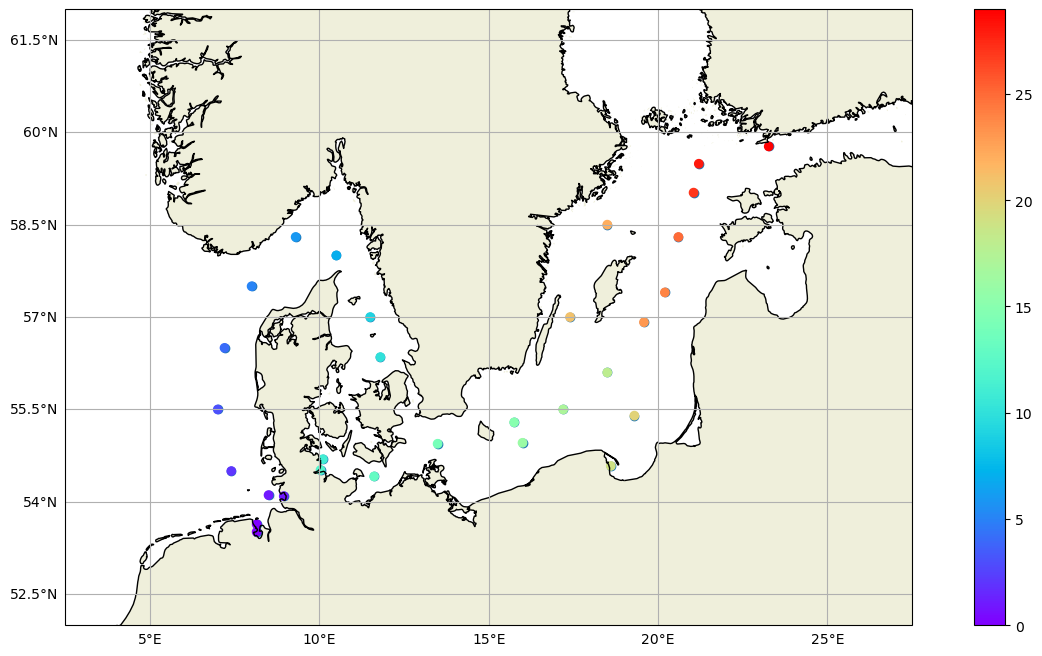

In [7]:
fig = plt.figure(figsize=mapsize)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_sample_points.plot(ax=ax_map)
gdf_sample_points.plot(ax=ax_map, column='order', cmap='rainbow', legend=True)
# ax_map.plot(gdf_sample_points.geometry.x, gdf_sample_points.geometry.y)
plt.show()

In [8]:
# Define the the radius of interest around the sample points
centroid = gdf_sample_points.dissolve().centroid
# Set the central position of the Projection to the centroid
crs_orthographic_centered = ccrs.Orthographic(
    central_longitude=centroid.x.values[0], 
    central_latitude=centroid.y.values[0]
    )

In [9]:
area_of_interest = (
    gpd.GeoDataFrame(
        gdf_sample_points.location_id,
        geometry=gdf_sample_points
        .to_crs(crs_orthographic_centered) # Reproject to pojection in meters
        .buffer(distance=1.25e5) # Set the Bufferdistance to 125 000 metres
        .to_crs(Geodetic()) # Reproject to Geodetic
        )
        .dissolve() # Dissolve the polygons to one single polygon
    )

In [10]:
# Build geodataframe for voronoi polygons
gdf_voronoi_polygons = (
        gdf_sample_points
        .set_geometry(gdf_sample_points.voronoi_polygons()) # exchange the points with voronoi polygons
        .clip(area_of_interest) # clip to radius
)

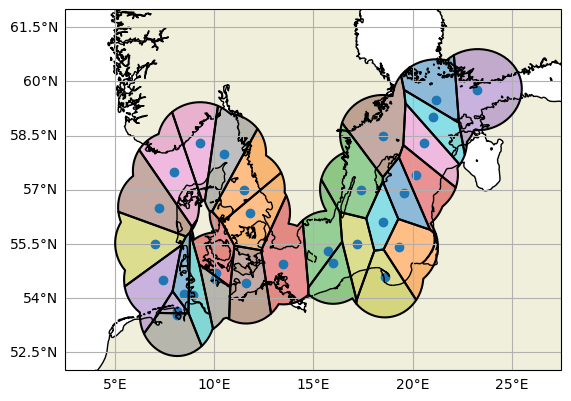

In [11]:
fig = plt.figure()
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_polygons.plot(ax=ax_map, alpha=0.5, column='location_id',)
gdf_voronoi_polygons.boundary.plot(ax=ax_map, color='k',)
gdf_sample_points.plot(ax=ax_map)
map_extent = ax_map.get_extent(crs=map_projection)
plt.show()

In [12]:
ocean_50m = cartopy.feature.NaturalEarthFeature('physical', 'ocean', '50m')

for i, poly in enumerate(ocean_50m.intersecting_geometries(map_extent)):
    if i == 0:
        polygon = list([poly])
    else:
        polygon.append(poly)
sea_polygon = gpd.GeoDataFrame(dict(geometry=polygon), crs=Geodetic()).clip(area_of_interest)
# devide by 10^6 because the unit we need is km^2 while th output unit is m^2
gdf_voronoi_polygons['sea_surface_area'] = (
    gdf_voronoi_polygons
    .clip(sea_polygon)
    .to_crs(crs=crs_orthographic_centered)
    .area/1e6
)
gdf_sample_points['sea_surface_area'] = gdf_voronoi_polygons.sea_surface_area

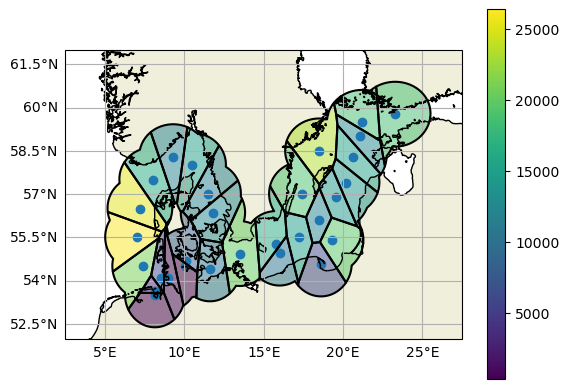

In [13]:
fig = plt.figure()
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_polygons.plot(ax=ax_map, alpha=0.5, column='sea_surface_area', legend=True)
gdf_voronoi_polygons.boundary.plot(ax=ax_map, color='k',)
gdf_sample_points.plot(ax=ax_map)
plt.show()

In [14]:
gdf_sample_points.to_file(output_path/'sample_points.geojson', driver='GeoJSON')
gdf_voronoi_polygons.to_file(output_path/'voronoi_polygons.geojson', driver='GeoJSON')